SEQUENTIAL BAYESIAN UPDATE OF COPAY EFFECT

MONTH 1
----------------------------------------
Posterior mean theta: -0.710
95% credible interval: [-1.008, -0.414]
Posterior OR: 0.498
P(copay reduces churn | data): 1.000
Effective Sample Size: 3344/20000

MONTH 2
----------------------------------------
Posterior mean theta: -0.557
95% credible interval: [-0.761, -0.355]
Posterior OR: 0.576
P(copay reduces churn | data): 1.000
Effective Sample Size: 2453/20000

MONTH 3
----------------------------------------
Posterior mean theta: -0.571
95% credible interval: [-0.738, -0.403]
Posterior OR: 0.567
P(copay reduces churn | data): 1.000
Effective Sample Size: 2027/20000

MONTH 4
----------------------------------------
Posterior mean theta: -0.568
95% credible interval: [-0.714, -0.424]
Posterior OR: 0.568
P(copay reduces churn | data): 1.000
Effective Sample Size: 1762/20000

MONTH 5
----------------------------------------
Posterior mean theta: -0.502
95% credible interval: [-0.630, -0.371

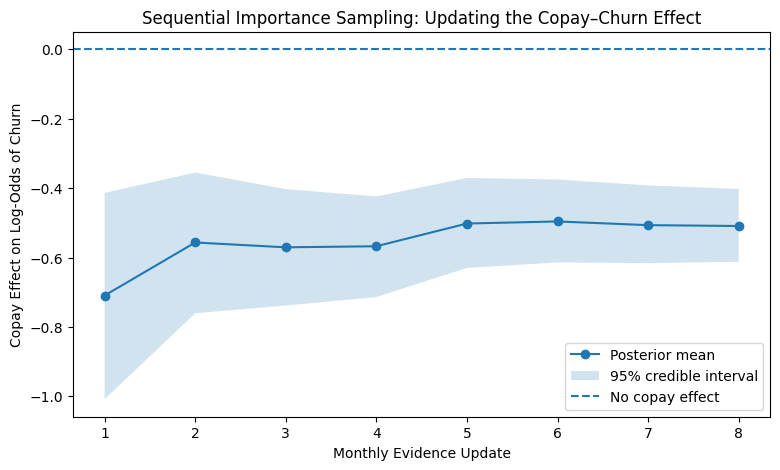



FINAL INTERPRETATION

After 8 sequential evidence updates:

Posterior mean copay effect:
    theta = -0.509

Posterior odds ratio:
    OR = 0.602

95% credible interval:
    [-0.612,
     -0.403]

Posterior probability that copay assistance
reduces churn:

    P(theta < 0 | all observed data)
    = 1.000



In [2]:
# ============================================================
# Sequential Importance Sampling (SIS) for a Churn Example
# ============================================================
#
# Business question:
# For Commercial patients, what is the effect of copay assistance
# on the probability of churn?
#
# theta = log-odds effect of copay assistance on churn
#
#   theta < 0  -> copay assistance is associated with LOWER churn
#   theta = 0  -> no association
#   theta > 0  -> copay assistance is associated with HIGHER churn
#
# SIS idea:
#
#   Prior p(theta)
#        ↓
#   particles theta_1,...,theta_N
#        ↓
#   Month 1 outcomes -> update particle weights
#        ↓
#   Posterior Month 1
#        ↓
#   Month 2 outcomes -> update SAME weights
#        ↓
#   Posterior Month 2
#        ↓
#       ...
#
#   w_k(t) ∝ w_k(t-1) * p(D_t | theta_k)
#
# NOTE:
# This is deliberately a simple teaching example. It treats the
# baseline churn probability as known. In a production model we
# would also estimate baseline risk and adjust for MPR, OOP,
# dosage/device, patient characteristics, etc.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit, logsumexp

np.random.seed(42)


# ------------------------------------------------------------
# 1. Generate example monthly Commercial-patient observations
# ------------------------------------------------------------
#
# Each row represents one patient observed during a particular
# monthly update.
#
# copay = 1 -> copay assistance
# copay = 0 -> no copay assistance
# churn = 1 -> churn
# churn = 0 -> continued/persistent
#
# For illustration only, we simulate a beneficial copay effect.

n_months = 8
patients_per_month = 500

true_baseline_logit = -0.20

# True simulated copay effect.
# Negative means lower churn.
true_theta = -0.50

monthly_data = {}

for month in range(1, n_months + 1):

    copay = np.random.binomial(
        1,
        0.40,
        patients_per_month
    )

    logit_p = (
        true_baseline_logit
        + true_theta * copay
    )

    p_churn = expit(logit_p)

    churn = np.random.binomial(
        1,
        p_churn
    )

    monthly_data[month] = pd.DataFrame({
        "month": month,
        "copay": copay,
        "churn": churn
    })


# ------------------------------------------------------------
# 2. Define prior over the unknown copay effect theta
# ------------------------------------------------------------
#
# Rather than storing the posterior analytically, SIS represents
# it using many particles.
#
# theta_k ~ Normal(0, 1)
#
# Initially all particles have equal probability.

N_PARTICLES = 20_000

theta_particles = np.random.normal(
    loc=0.0,
    scale=1.0,
    size=N_PARTICLES
)

log_weights = np.full(
    N_PARTICLES,
    -np.log(N_PARTICLES)
)


# ------------------------------------------------------------
# 3. Likelihood function
# ------------------------------------------------------------
#
# For each possible theta particle:
#
# logit(P(churn_i)) =
#       baseline_logit + theta * copay_i
#
# The likelihood tells us how compatible each theta particle
# is with the newly observed churn data.

def log_likelihood(theta_particles, data):

    copay = data["copay"].values
    churn = data["churn"].values

    result = np.zeros(len(theta_particles))

    for i, theta in enumerate(theta_particles):

        eta = (
            true_baseline_logit
            + theta * copay
        )

        p = expit(eta)

        # Numerical protection
        p = np.clip(p, 1e-12, 1 - 1e-12)

        result[i] = np.sum(
            churn * np.log(p)
            + (1 - churn) * np.log(1 - p)
        )

    return result


# ------------------------------------------------------------
# 4. Helper functions
# ------------------------------------------------------------

def normalize_log_weights(log_weights):

    log_weights = (
        log_weights
        - logsumexp(log_weights)
    )

    weights = np.exp(log_weights)

    return log_weights, weights


def effective_sample_size(weights):

    return 1.0 / np.sum(weights ** 2)


def weighted_quantile(values, weights, quantiles):

    sorter = np.argsort(values)

    values = values[sorter]
    weights = weights[sorter]

    cumulative_weights = np.cumsum(weights)
    cumulative_weights /= cumulative_weights[-1]

    return np.interp(
        quantiles,
        cumulative_weights,
        values
    )


# ------------------------------------------------------------
# 5. Sequential Importance Sampling
# ------------------------------------------------------------

history = []

print("=" * 75)
print("SEQUENTIAL BAYESIAN UPDATE OF COPAY EFFECT")
print("=" * 75)

for month in range(1, n_months + 1):

    new_data = monthly_data[month]

    # --------------------------------------------------------
    # SIS update
    #
    # log w_k(t)
    # =
    # log w_k(t-1)
    # +
    # log p(D_t | theta_k)
    # --------------------------------------------------------

    ll = log_likelihood(
        theta_particles,
        new_data
    )

    log_weights += ll

    log_weights, weights = normalize_log_weights(
        log_weights
    )

    # --------------------------------------------------------
    # Posterior summaries
    # --------------------------------------------------------

    posterior_mean = np.sum(
        weights * theta_particles
    )

    ci_low, ci_high = weighted_quantile(
        theta_particles,
        weights,
        [0.025, 0.975]
    )

    # Probability that copay reduces churn
    prob_benefit = np.sum(
        weights[theta_particles < 0]
    )

    # Convert theta to an odds ratio
    posterior_or = np.sum(
        weights * np.exp(theta_particles)
    )

    ESS = effective_sample_size(weights)

    history.append({
        "month": month,
        "posterior_mean": posterior_mean,
        "CI_low": ci_low,
        "CI_high": ci_high,
        "posterior_OR": posterior_or,
        "P_copay_reduces_churn": prob_benefit,
        "ESS": ESS
    })

    print(f"\nMONTH {month}")
    print("-" * 40)

    print(
        f"Posterior mean theta: "
        f"{posterior_mean:.3f}"
    )

    print(
        f"95% credible interval: "
        f"[{ci_low:.3f}, {ci_high:.3f}]"
    )

    print(
        f"Posterior OR: "
        f"{posterior_or:.3f}"
    )

    print(
        "P(copay reduces churn | data): "
        f"{prob_benefit:.3f}"
    )

    print(
        f"Effective Sample Size: "
        f"{ESS:.0f}/{N_PARTICLES}"
    )


# ------------------------------------------------------------
# 6. Examine how the posterior evolves
# ------------------------------------------------------------

history_df = pd.DataFrame(history)

print("\n")
print("=" * 75)
print("POSTERIOR EVOLUTION")
print("=" * 75)

print(
    history_df.round(3).to_string(index=False)
)


# ------------------------------------------------------------
# 7. Plot sequential posterior estimate
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    history_df["month"],
    history_df["posterior_mean"],
    marker="o",
    label="Posterior mean"
)

plt.fill_between(
    history_df["month"],
    history_df["CI_low"],
    history_df["CI_high"],
    alpha=0.2,
    label="95% credible interval"
)

plt.axhline(
    0,
    linestyle="--",
    label="No copay effect"
)

plt.xlabel("Monthly Evidence Update")
plt.ylabel("Copay Effect on Log-Odds of Churn")
plt.title(
    "Sequential Importance Sampling: "
    "Updating the Copay–Churn Effect"
)

plt.legend()
plt.show()


# ------------------------------------------------------------
# 8. Final posterior interpretation
# ------------------------------------------------------------

final = history_df.iloc[-1]

print("\n")
print("=" * 75)
print("FINAL INTERPRETATION")
print("=" * 75)

print(
    f"""
After {n_months} sequential evidence updates:

Posterior mean copay effect:
    theta = {final['posterior_mean']:.3f}

Posterior odds ratio:
    OR = {final['posterior_OR']:.3f}

95% credible interval:
    [{final['CI_low']:.3f},
     {final['CI_high']:.3f}]

Posterior probability that copay assistance
reduces churn:

    P(theta < 0 | all observed data)
    = {final['P_copay_reduces_churn']:.3f}
"""
)


# ------------------------------------------------------------
# 9. How this would map to the real churn workflow
# ------------------------------------------------------------
#
# Instead of:
#
#     logit(P(churn)) =
#         beta0 + theta * copay
#
# the real model could use:
#
#     logit(P(churn_i,t)) =
#
#         beta0
#       + beta_MPR * MPR_i,t
#       + beta_OOP * OOP_i,t
#       + beta_QM * QM_i
#       + beta_gap * refill_gap_i,t
#       + theta_copay * copay_i,t
#
#
# A particle would then be a VECTOR:
#
# particle_k =
# [
#     beta0,
#     beta_MPR,
#     beta_OOP,
#     beta_QM,
#     beta_gap,
#     theta_copay
# ]
#
# Every month:
#
# previous posterior
#       ↓
# new claims/refill data
#       ↓
# likelihood of new observations
#       ↓
# update particle weights
#       ↓
# new posterior
#       ↓
# calculate:
#
# P(churn | patient state)
# P(copay reduces churn | data)
# expected intervention benefit
#
#       ↓
#
# Bayesian decision / optimization layer
#
# NOTE:
# Pure SIS eventually suffers from weight degeneracy
# (ESS becomes small). The natural next step is Sequential
# Monte Carlo / particle filtering:
#
# SIS
#   +
# ESS monitoring
#   +
# resampling when ESS is low
#   +
# optional particle rejuvenation
#
# which is generally more suitable for a long-running
# sequential churn-monitoring system.
# ============================================================